# Bank Account Fraud (BAF) — EDA, Preprocessing, and Imbalance Handling

Comparing oversampling strategies on the **Bank Account Fraud** dataset (`Base.csv`, NeurIPS 2022).

| Property | Value |
|---|---|
| Rows / columns | 1,000,000 x 32 |
| Target | `fraud_bool` |
| Fraud rate | 11,029 / 1,000,000 = **1.10%** (1:90) |
| Feature types | **mixed** — 19 numeric, 7 binary flags, **5 categorical** |
| Missing values | encoded as **`-1` sentinels**, not `NaN` |
| Duplicates | none |

**Why this dataset suits the SMOTE-vs-GAN question.** Two properties that `creditcard.csv` lacked:

1. **~8,800 fraud rows in the training split** — enough data for a generative model to actually estimate a distribution.
2. **Genuine categorical features** — this is the mixed-type setting CTGAN was designed for, and the one place SMOTE has a principled weakness (interpolating a one-hot column produces fractional, meaningless categories).

**Methodological note.** To keep the comparison fair we evaluate **four** models, and every resampler targets the *same* minority ratio (`SAMPLING_STRATEGY`):

- **Baseline** — no resampling
- **SMOTE** — interpolation on the one-hot encoded matrix (the naive baseline)
- **SMOTE-NC** — SMOTE variant that handles categoricals properly (**the fair baseline**)
- **CTGAN** — generative model trained on the fraud minority

Comparing CTGAN only against plain SMOTE on mixed-type data would stack the deck, so SMOTE-NC is included as the honest opponent.

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Colorblind-safe palette (Okabe-Ito)
BLUE, ORANGE, VERMILLION, GREEN = "#0072B2", "#E69F00", "#D55E00", "#009E73"
CLASS_COLORS = [BLUE, VERMILLION]  # 0 = legitimate, 1 = fraud

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "grid.alpha": 0.3,
    "axes.edgecolor": "#888888",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", None)

## 1. Dataset overview

In [126]:
df = pd.read_csv("../data/Base.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 1,000,000 rows x 32 columns


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [128]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,4769.781965,4856.324016,184.361849,9.503544,130.989595,0.529886,0.417077,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,1479.212612,919.843934,459.625329,5.033792,69.681812,0.499106,0.493076,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,1300.307314,2825.748405,0.000000,0.000000,-170.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,3593.179135,4268.368423,1.000000,6.000000,83.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,4749.921161,4913.436941,9.000000,9.000000,122.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,5752.574191,5488.083356,25.000000,13.000000,178.000000,1.000000,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,9506.896596,6994.764201,2385.000000,39.000000,389.000000,1.000000,1.000000,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


## 2. Variable types

Four groups: the **target**, true **categorical** (text) columns, **binary flags** (0/1), and continuous/count **numeric** columns. Binary flags are numeric in dtype but categorical in meaning, so they are kept separate — this distinction matters later for both SMOTE-NC and CTGAN's `discrete_columns`.

In [129]:
TARGET = "fraud_bool"

categorical_cols = df.select_dtypes(include="object").columns.tolist()
binary_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != TARGET and set(df[c].dropna().unique()) <= {0, 1}
]
numerical_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != TARGET and c not in binary_cols
]

print(f"Target       : {TARGET}")
print(f"Categorical  ({len(categorical_cols)}): {categorical_cols}")
print(f"Binary flags ({len(binary_cols)}): {binary_cols}")
print(f"Numeric      ({len(numerical_cols)}): {numerical_cols}")

print("\nCategorical cardinality:")
for c in categorical_cols:
    print(f"  {c:20s} {df[c].nunique()} levels")

# Constant columns carry no signal
constant = [c for c in df.columns if df[c].nunique() <= 1]
print(f"\nConstant columns (no information): {constant}")

Target       : fraud_bool
Categorical  (5): ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Binary flags (7): ['email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards', 'foreign_request', 'keep_alive_session', 'device_fraud_count']
Numeric      (19): ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'bank_months_count', 'proposed_credit_limit', 'session_length_in_minutes', 'device_distinct_emails_8w', 'month']

Categorical cardinality:
  payment_type         5 levels
  employment_status    7 levels
  housing_status       7 levels
  source               2 levels
  device_os            5 levels

Constant columns (no information): ['device_fraud_count']


In [130]:
for col in categorical_cols:
    print(f"\n{col}  ({df[col].nunique()} unique)")
    print(df[col].value_counts().to_string())


payment_type  (5 unique)
payment_type
AB    370554
AA    258249
AC    252071
AD    118837
AE       289

employment_status  (7 unique)
employment_status
CA    730252
CB    138288
CF     44034
CC     37758
CD     26522
CE     22693
CG       453

housing_status  (7 unique)
housing_status
BC    372143
BB    260965
BA    169675
BE    169135
BD     26161
BF      1669
BG       252

source  (2 unique)
source
INTERNET    992952
TELEAPP       7048

device_os  (5 unique)
device_os
other        342728
linux        332712
windows      263506
macintosh     53826
x11            7228


## 3. Class distribution (imbalance)

1.10% fraud (1:90). Far less extreme than the 1:578 of `creditcard.csv` — and critically, the **absolute** minority count (11,029) is large enough for a generative model.

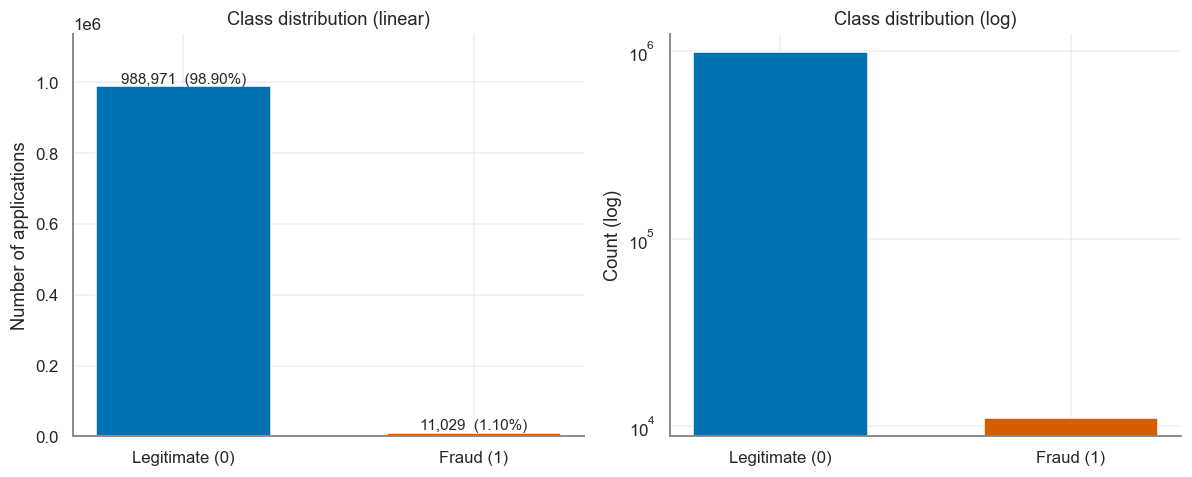

Fraud rate      : 1.1029%
Imbalance ratio : 1 fraud : 90 legitimate


In [131]:
counts = df[TARGET].value_counts().sort_index()
total = counts.sum()
labels = ["Legitimate (0)", "Fraud (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars = axes[0].bar(labels, counts.values, color=CLASS_COLORS, width=0.6)
for bar, c in zip(bars, counts.values):
    axes[0].annotate(f"{c:,}  ({c / total:.2%})",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Number of applications")
axes[0].set_title("Class distribution (linear)")
axes[0].margins(y=0.15)

axes[1].bar(labels, counts.values, color=CLASS_COLORS, width=0.6)
axes[1].set_yscale("log")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Class distribution (log)")

plt.tight_layout()
plt.show()

print(f"Fraud rate      : {counts[1] / total:.4%}")
print(f"Imbalance ratio : 1 fraud : {counts[0] / counts[1]:.0f} legitimate")

## 4. Missing values & duplicates

BAF encodes missing values as **`-1`**, not `NaN`, so a plain `isna()` check reports a complete dataset and is misleading.

We detect sentinels data-driven: a numeric column is sentinel-encoded if it contains `-1` **and has no values below `-1`**. That rule deliberately spares `intended_balcon_amount`, which has genuinely negative values (min ≈ −15.5) and is *not* sentinel-encoded.

In [132]:
# Explicit NaN
nan_counts = df.isna().sum()
print("Columns with explicit NaN:")
print(nan_counts[nan_counts > 0].to_string() if nan_counts.any() else "  None")

# Sentinel-encoded missingness
sentinel_cols = [
    c for c in numerical_cols
    if (df[c] == -1).any() and (df[c] < -1).sum() == 0
]
sent = pd.DataFrame({
    "n_missing": [(df[c] == -1).sum() for c in sentinel_cols],
    "pct_missing": [round((df[c] == -1).mean() * 100, 2) for c in sentinel_cols],
}, index=sentinel_cols).sort_values("pct_missing", ascending=False)

print(f"\nSentinel (-1) encoded columns: {sentinel_cols}")
print(f"\nExcluded by the rule (genuine negatives): "
      f"{[c for c in numerical_cols if (df[c] < -1).any()]}")
print(f"\nDuplicate rows: {int(df.duplicated().sum()):,}")
sent

Columns with explicit NaN:
  None

Sentinel (-1) encoded columns: ['prev_address_months_count', 'current_address_months_count', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']

Excluded by the rule (genuine negatives): ['intended_balcon_amount', 'velocity_6h', 'credit_risk_score']

Duplicate rows: 0


,n_missing,pct_missing
prev_address_months_count,712920,71.29
bank_months_count,253635,25.36
current_address_months_count,4254,0.43
session_length_in_minutes,2015,0.20
device_distinct_emails_8w,359,0.04


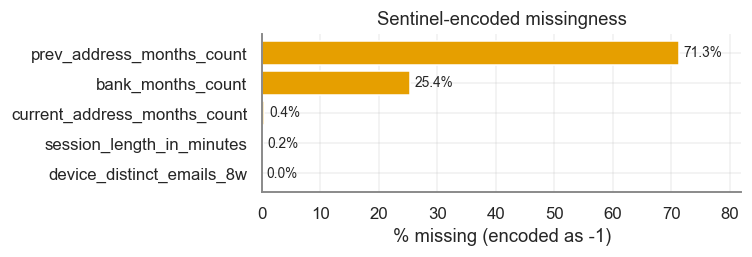

In [133]:
if not sent.empty:
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.5 * len(sent))))
    ax.barh(sent.index[::-1], sent["pct_missing"][::-1], color=ORANGE)
    ax.set_xlabel("% missing (encoded as -1)")
    ax.set_title("Sentinel-encoded missingness")
    for i, v in enumerate(sent["pct_missing"][::-1]):
        ax.annotate(f"{v:.1f}%", (v, i), xytext=(3, 0),
                    textcoords="offset points", va="center", fontsize=9)
    ax.margins(x=0.15)
    plt.tight_layout()
    plt.show()

## 5. Feature distributions

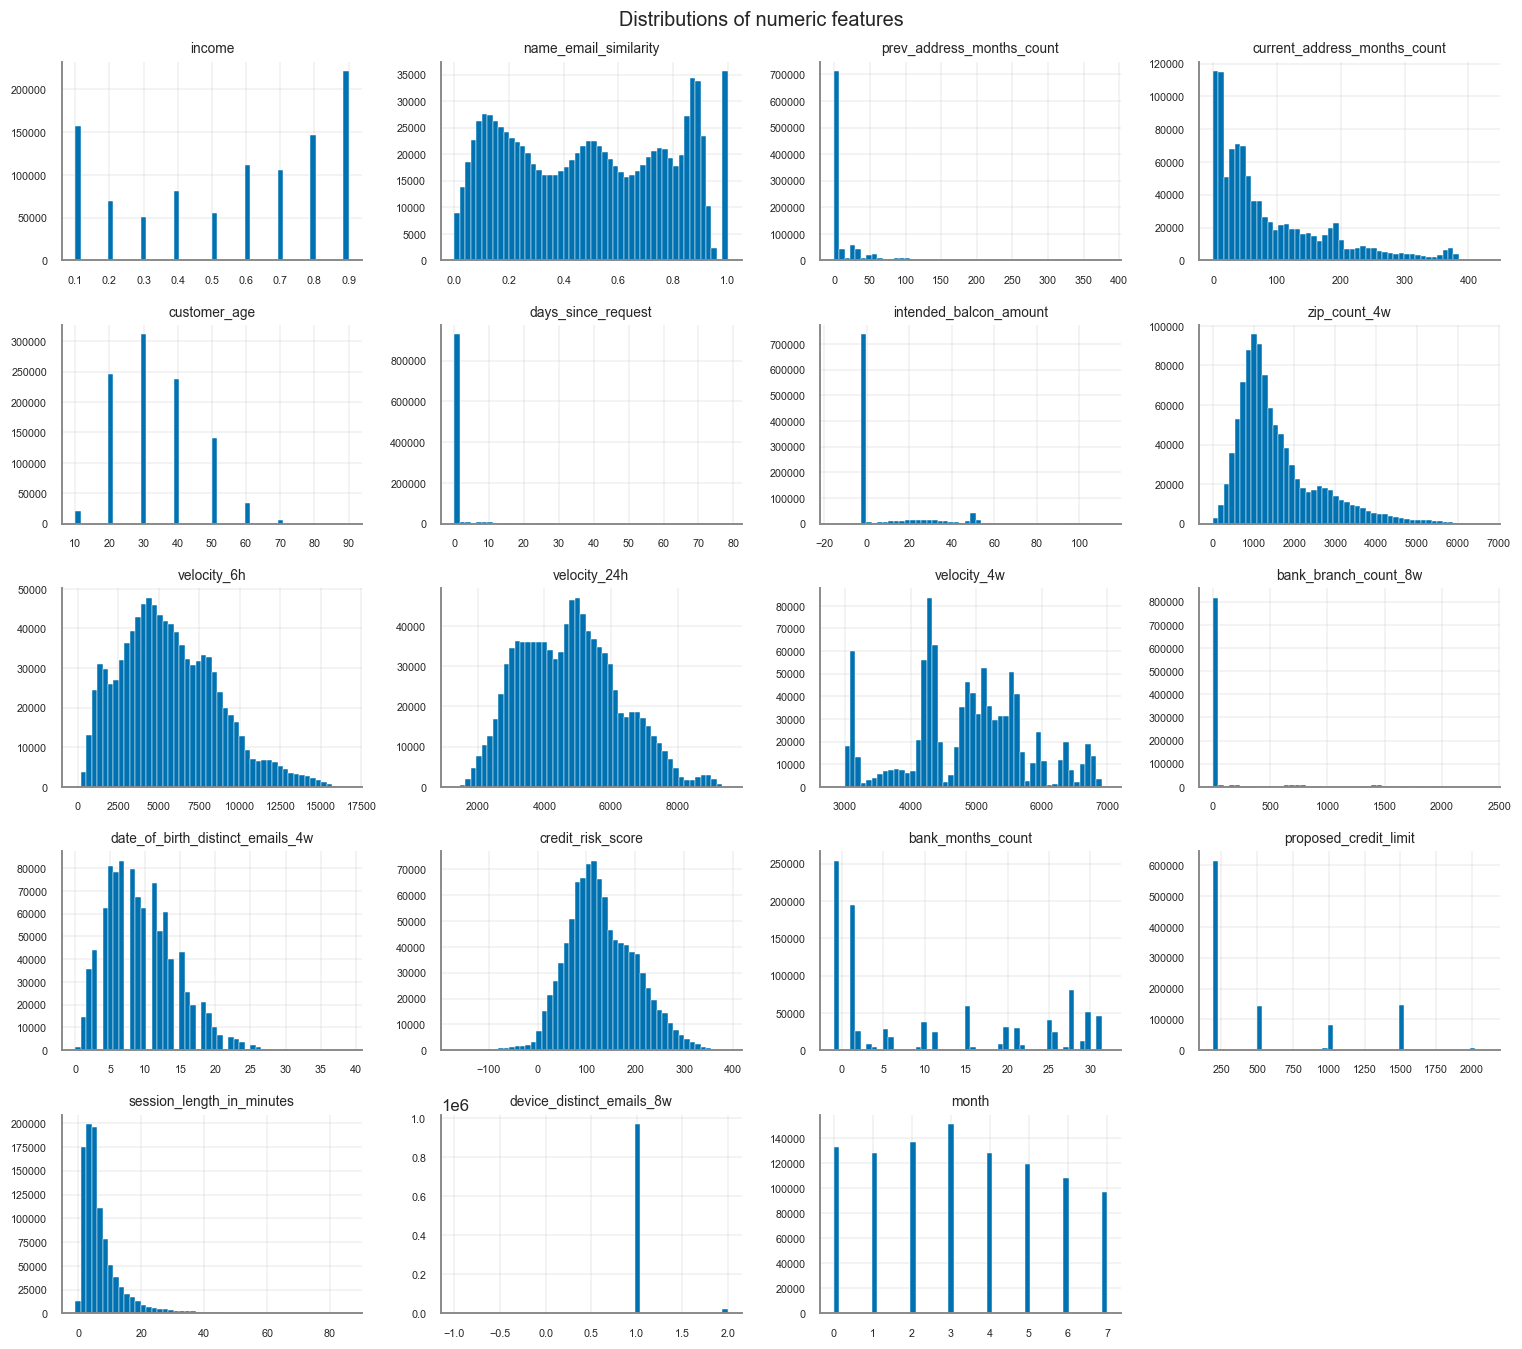

In [134]:
ncols = 4
nrows = int(np.ceil(len(numerical_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))

for ax, col in zip(axes.flat, numerical_cols):
    ax.hist(df[col], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes.flat[len(numerical_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of numeric features", fontsize=13)
plt.tight_layout()
plt.show()

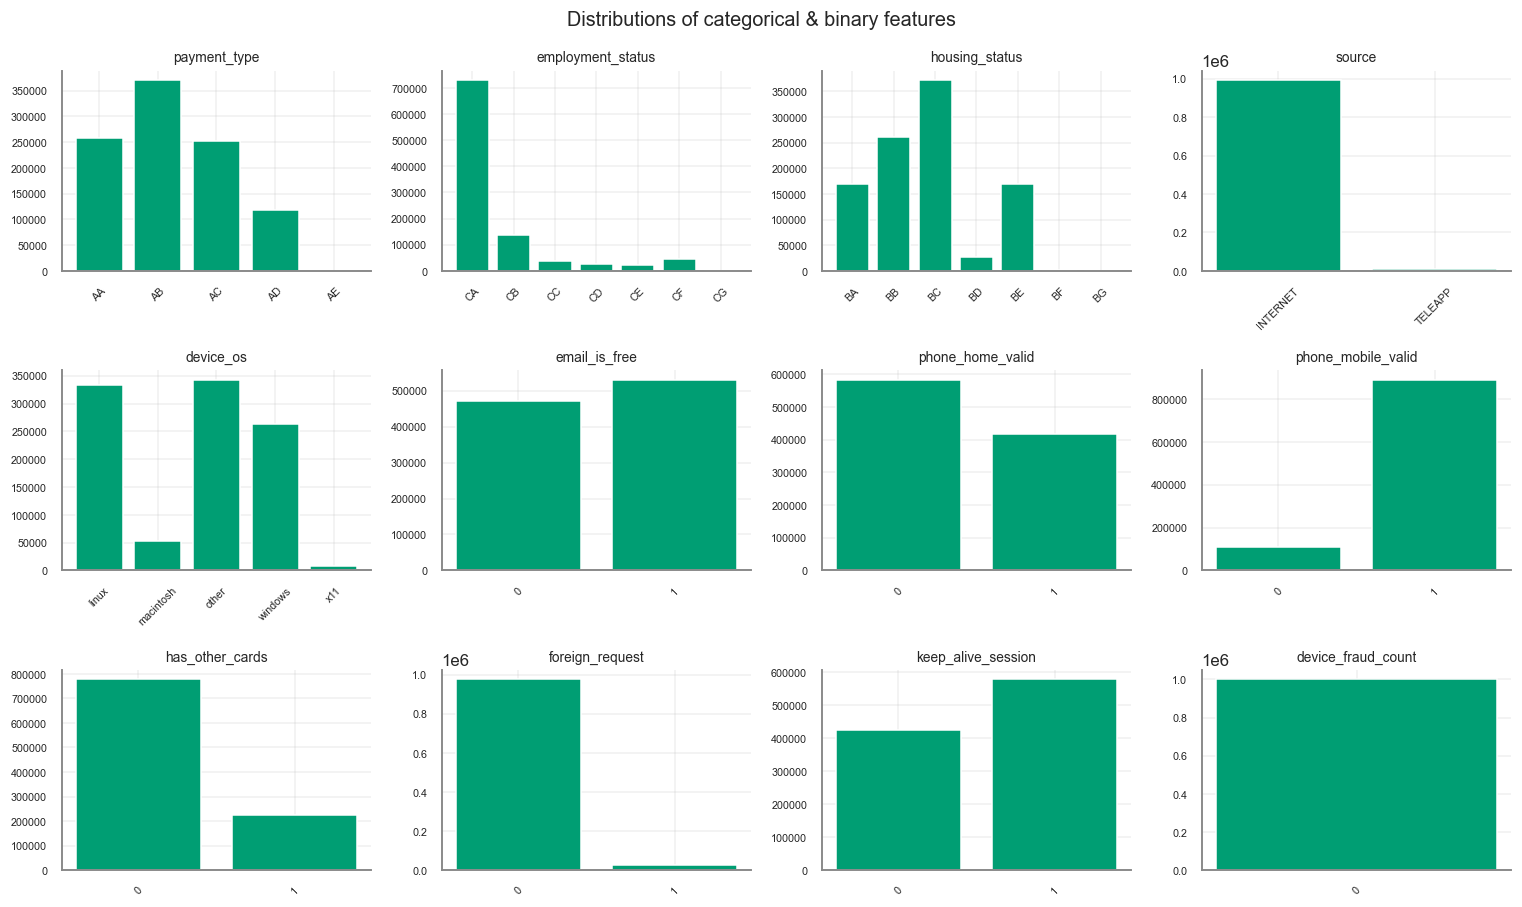

In [135]:
cat_like = categorical_cols + binary_cols
ncols = 4
nrows = int(np.ceil(len(cat_like) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))

for ax, col in zip(axes.flat, cat_like):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=GREEN)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

for ax in axes.flat[len(cat_like):]:
    ax.set_visible(False)

fig.suptitle("Distributions of categorical & binary features", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Outlier detection

Measured, not blindly removed — in fraud detection the signal often lives in the tails.

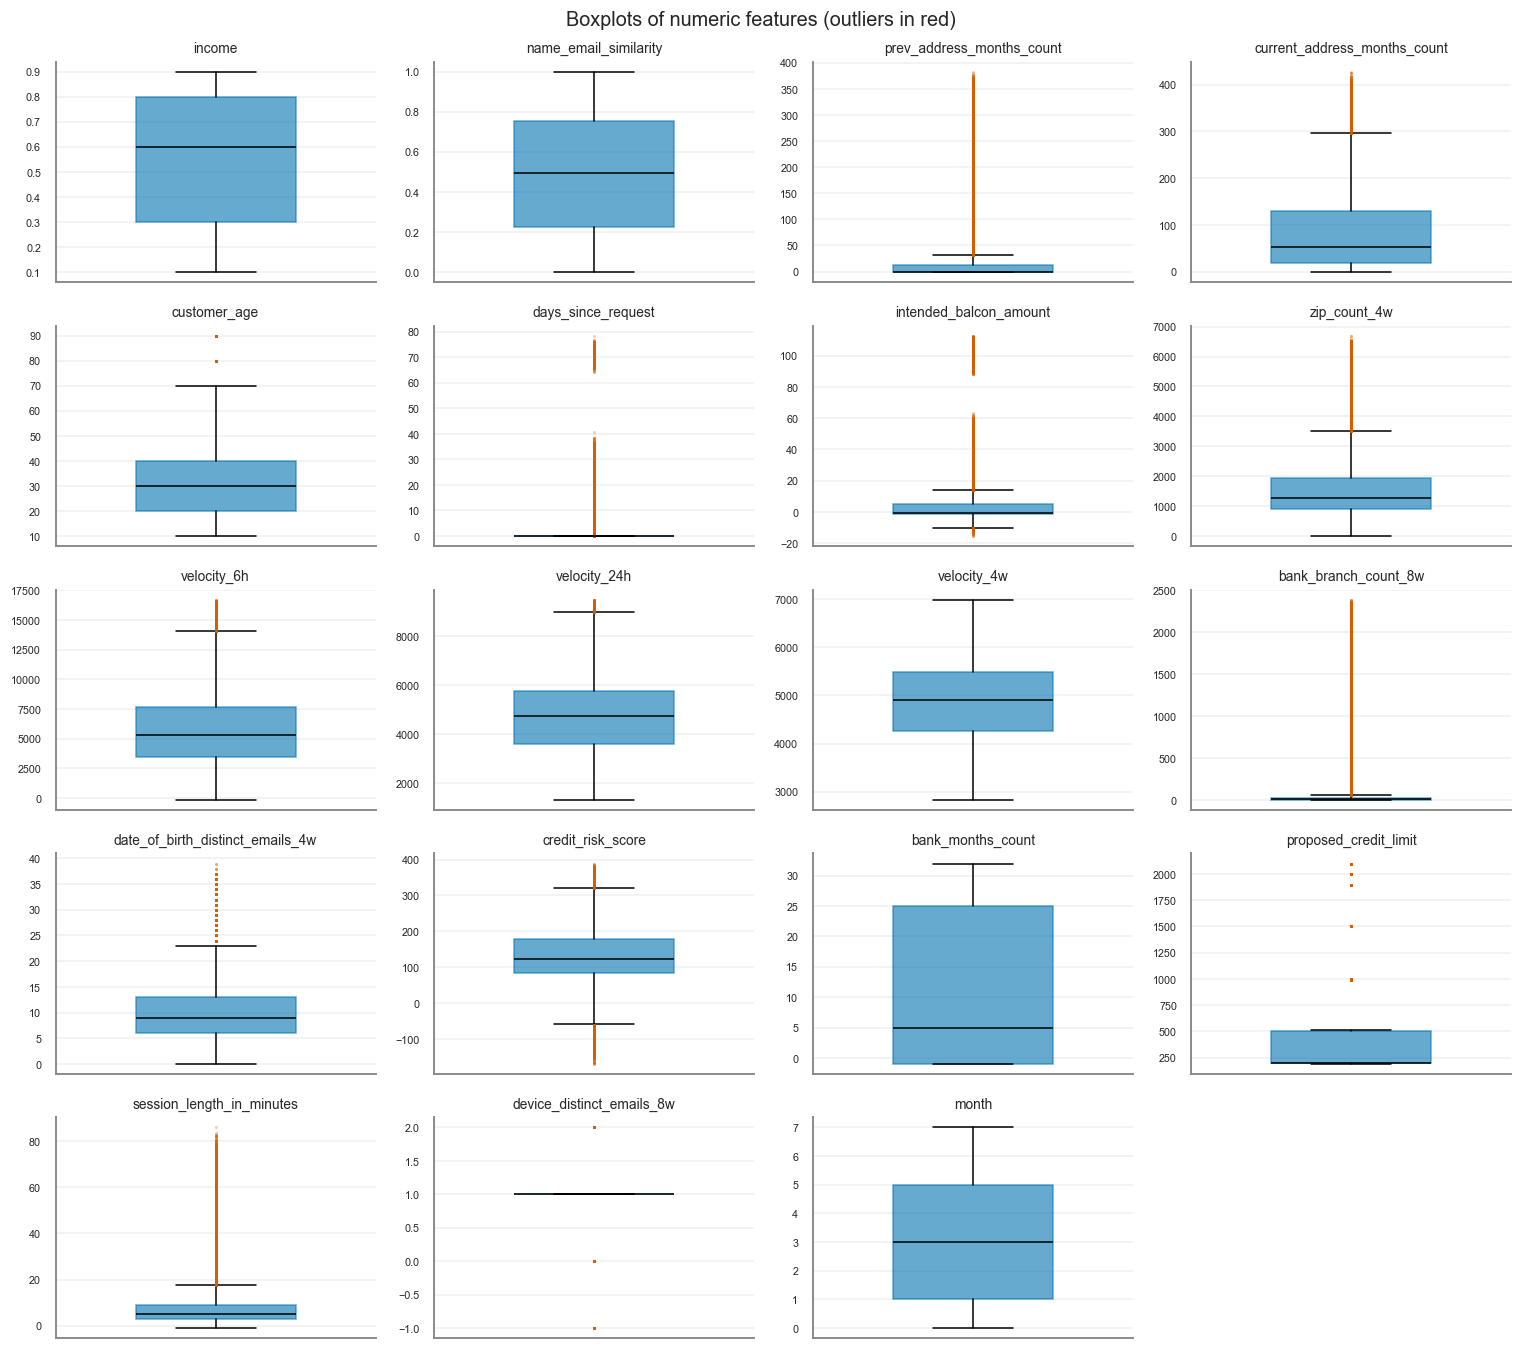

In [136]:
ncols = 4
nrows = int(np.ceil(len(numerical_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))

flier = dict(marker="o", markersize=2, markerfacecolor=VERMILLION,
             markeredgecolor="none", alpha=0.3)
for ax, col in zip(axes.flat, numerical_cols):
    ax.boxplot(df[col], vert=True, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=BLUE, alpha=0.6, edgecolor=BLUE),
               medianprops=dict(color="black"), flierprops=flier)
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=7)

for ax in axes.flat[len(numerical_cols):]:
    ax.set_visible(False)

fig.suptitle("Boxplots of numeric features (outliers in red)", fontsize=13)
plt.tight_layout()
plt.show()

In [137]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return int(mask.sum()), mask.mean() * 100

outlier_summary = (pd.DataFrame(
    [{"feature": c, "n_outliers": n, "pct_outliers": round(p, 2)}
     for c in numerical_cols for n, p in [iqr_outliers(df[c])]])
    .sort_values("pct_outliers", ascending=False).reset_index(drop=True))
outlier_summary

,feature,n_outliers,pct_outliers
0,proposed_credit_limit,241742,24.17
1,intended_balcon_amount,222702,22.27
2,bank_branch_count_8w,175243,17.52
3,prev_address_months_count,157320,15.73
4,days_since_request,94834,9.48
5,session_length_in_minutes,78789,7.88
6,zip_count_4w,59871,5.99
7,current_address_months_count,41001,4.10
8,device_distinct_emails_8w,31933,3.19
9,date_of_birth_distinct_emails_4w,9734,0.97


## 7. Correlation matrix

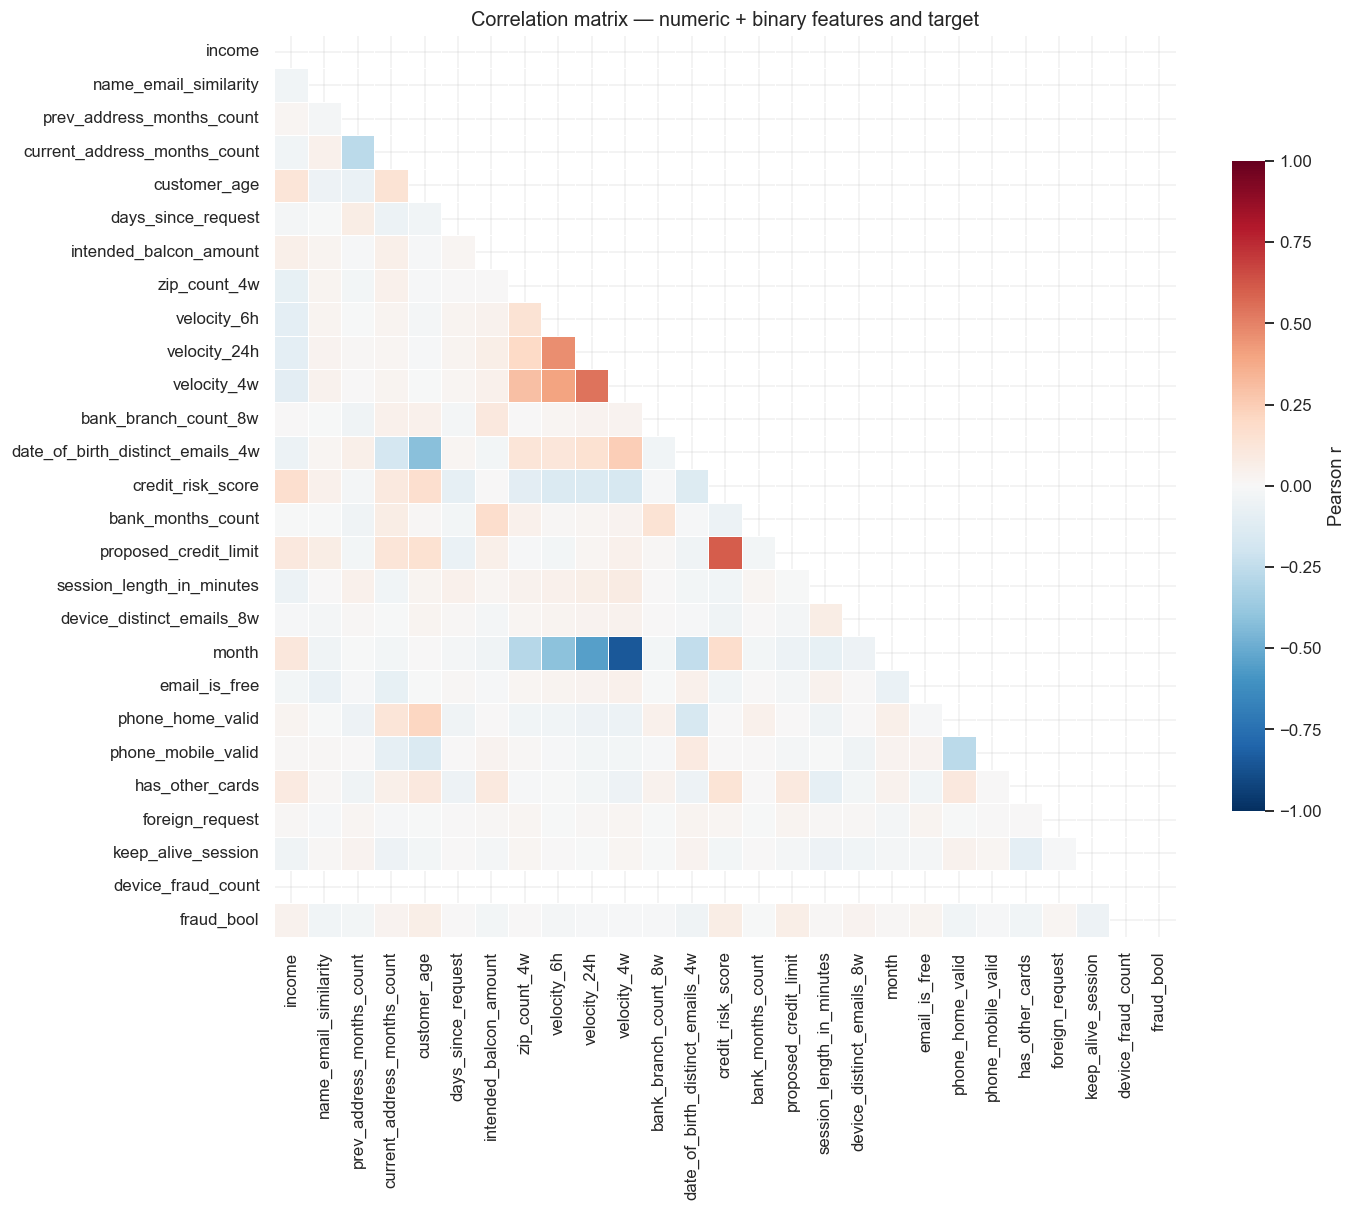

In [138]:
corr = df[numerical_cols + binary_cols + [TARGET]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix — numeric + binary features and target", fontsize=13)
plt.tight_layout()
plt.show()

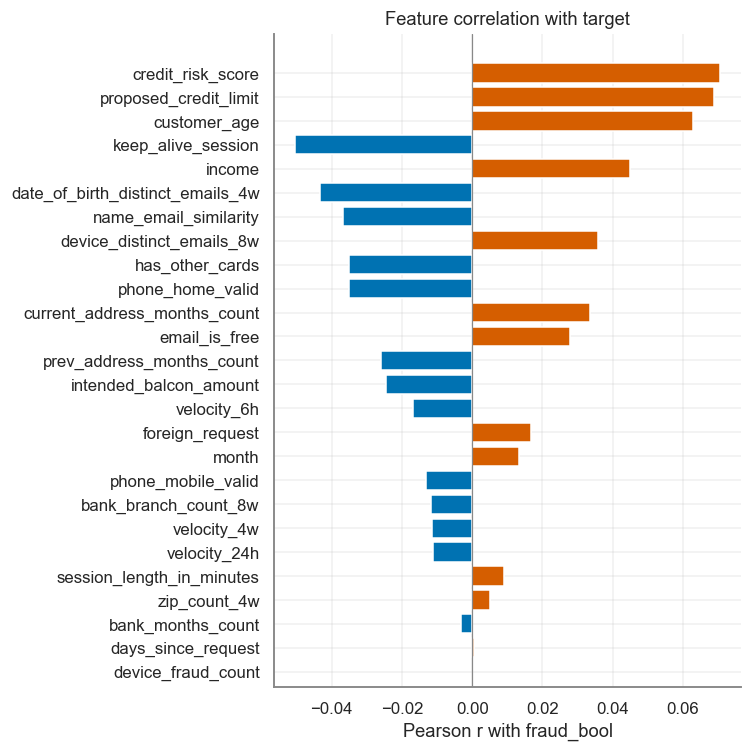

,corr_with_fraud
credit_risk_score,0.070624
proposed_credit_limit,0.068907
customer_age,0.062959
keep_alive_session,-0.050296
income,0.045079
date_of_birth_distinct_emails_4w,-0.043224
name_email_similarity,-0.036720
device_distinct_emails_8w,0.035704
has_other_cards,-0.035156
phone_home_valid,-0.035128


In [139]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
colors = [VERMILLION if v > 0 else BLUE for v in target_corr[::-1]]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors)
ax.axvline(0, color="#888888", linewidth=0.8)
ax.set_xlabel("Pearson r with fraud_bool")
ax.set_title("Feature correlation with target")
plt.tight_layout()
plt.show()

target_corr.to_frame("corr_with_fraud").head(15)

## 8. Preprocessing

| Step | Action |
|---|---|
| Sentinel decoding | `-1` → `NaN` in the 5 detected columns |
| Excessive missingness | drop columns > 40% missing |
| Split | stratified 80/20, **before** any fitting |
| Impute | median (numeric), mode (categorical/binary) |
| Scale | `RobustScaler` on numeric |
| Encode | one-hot on categoricals |

**Why scale**, given Random Forest is scale-invariant? Because **SMOTE is distance-based (k-NN)**. `velocity_4w` runs into the thousands while `income` is on [0, 1]; unscaled, the velocity features would dominate every neighbour computation.

### 8.1 Decode sentinels and drop excessive missingness

In [140]:
data = df.copy()
data[sentinel_cols] = data[sentinel_cols].replace(-1, np.nan)

miss_pct = data.isna().mean().sort_values(ascending=False)
MISSING_THRESHOLD = 0.40

high_missing = miss_pct[miss_pct > MISSING_THRESHOLD].index.tolist()
data = data.drop(columns=high_missing)
print(f"Dropped (> {MISSING_THRESHOLD:.0%} missing): {high_missing}")

categorical_features = [c for c in categorical_cols if c in data.columns]
binary_features = [c for c in binary_cols if c in data.columns]
numeric_features = [c for c in numerical_cols if c in data.columns]

print(f"\nRetained -> numeric: {len(numeric_features)}, "
      f"binary: {len(binary_features)}, categorical: {len(categorical_features)}")
print("\nRemaining missingness (%):")
print((data.isna().mean() * 100).round(2).loc[lambda s: s > 0].to_string())

Dropped (> 40% missing): ['prev_address_months_count']

Retained -> numeric: 18, binary: 7, categorical: 5

Remaining missingness (%):
current_address_months_count     0.43
bank_months_count               25.36
session_length_in_minutes        0.20
device_distinct_emails_8w        0.04


### 8.2 Train/test split

In [141]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=[TARGET])
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Train fraud: {int(y_train.sum()):,} ({y_train.mean():.4%})")
print(f"Test  fraud: {int(y_test.sum()):,} ({y_test.mean():.4%})")

Train: (800000, 30)   Test: (200000, 30)
Train fraud: 8,823 (1.1029%)
Test  fraud: 2,206 (1.1030%)


### 8.3 Impute, scale, encode (fit on train only)

In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", RobustScaler())]), numeric_features),
        ("bin", SimpleImputer(strategy="most_frequent"), binary_features),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]),
         categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_prep = preprocessor.fit_transform(X_train)   # fit on TRAIN only
X_test_prep = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=feature_names, index=X_test.index)

print(f"Preprocessed train: {X_train_prep.shape}   test: {X_test_prep.shape}")
print(f"Any NaN? train={X_train_prep.isna().any().any()}, test={X_test_prep.isna().any().any()}")
X_train_prep.head()

Preprocessed train: (800000, 51)   test: (200000, 51)
Any NaN? train=False, test=False


,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,bank_months_count,proposed_credit_limit,session_length_in_minutes,device_distinct_emails_8w,month,email_is_free,phone_home_valid,phone_mobile_valid,has_other_cards,foreign_request,keep_alive_session,device_fraud_count,payment_type_AA,payment_type_AB,payment_type_AC,payment_type_AD,payment_type_AE,employment_status_CA,employment_status_CB,employment_status_CC,employment_status_CD,employment_status_CE,employment_status_CF,employment_status_CG,housing_status_BA,housing_status_BB,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
39111,0.2,-0.495223,0.090909,1.0,0.499420,8.232755,0.040000,1.754032,0.772147,0.889788,-0.083333,0.571429,-0.263158,0.45,4.333333,-0.268467,0.0,-0.75,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
822700,-0.8,0.822438,-0.263636,2.0,-0.052896,2.631288,-0.409524,1.036527,0.737074,-0.081134,-0.333333,-0.571429,0.231579,0.25,1.000000,0.342303,0.0,0.75,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
914415,-1.0,0.313644,-0.463636,0.5,1.601194,-0.092757,-0.977143,-0.733467,-0.924514,-1.506909,0.208333,-0.571429,-0.368421,0.55,0.000000,-0.796608,0.0,1.00,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
581307,0.4,0.532831,0.627273,0.0,-0.501573,0.046342,-0.350476,0.014354,-0.092222,-0.565630,-0.375000,-0.571429,0.884211,-0.70,1.000000,-0.078499,0.0,0.25,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
603136,0.6,0.945077,-0.400000,-0.5,-0.226456,0.052555,2.706667,0.497494,0.056539,-0.543542,0.208333,0.285714,-0.084211,-0.70,0.000000,0.726370,0.0,0.25,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### 8.4 An imputed *raw* training frame

SMOTE-NC and CTGAN both operate on the **original mixed-type feature space** (that is the whole point of using them), but neither accepts `NaN`. So we build one imputed-but-unencoded frame, using **training statistics only**, shared by both.

In [143]:
num_medians = X_train[numeric_features].median()
cat_modes = X_train[categorical_features].mode().iloc[0]
bin_modes = X_train[binary_features].mode().iloc[0]


def fill_frame(X):
    """Impute with TRAIN statistics, keeping the raw mixed-type schema."""
    Xf = X.copy()
    Xf[numeric_features] = Xf[numeric_features].fillna(num_medians)
    Xf[categorical_features] = Xf[categorical_features].fillna(cat_modes)
    Xf[binary_features] = Xf[binary_features].fillna(bin_modes)
    return Xf


X_train_filled = fill_frame(X_train)

print("Raw imputed training frame:", X_train_filled.shape)
print("Any NaN?", bool(X_train_filled.isna().any().any()))
print("dtypes:", dict(X_train_filled.dtypes.value_counts().astype(int)))
X_train_filled.head()

Raw imputed training frame: (800000, 30)
Any NaN? False
dtypes: {dtype('int64'): np.int64(13), dtype('float64'): np.int64(12), dtype('O'): np.int64(5)}


,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
39111,0.7,0.229712,63.0,50,0.024720,50.674001,AA,1305,12764.326278,6418.672862,5998.527006,7,13,CA,97,1,BC,0,1,24.0,1,1500.0,0,INTERNET,3.580550,linux,0,1.0,0,0
822700,0.2,0.928428,24.0,70,0.014153,15.631407,AA,833,9717.635327,6342.913428,4814.609668,1,5,CC,144,0,BD,1,0,20.0,0,500.0,0,INTERNET,7.087779,other,1,1.0,0,6
914415,0.1,0.658630,2.0,40,0.045801,-1.410133,AB,237,2201.833206,2753.815567,3076.055489,14,5,CA,87,1,BC,1,1,26.0,0,200.0,0,INTERNET,0.547804,other,1,1.0,0,7
581307,0.8,0.774858,122.0,30,0.005569,-0.539938,AB,895,5377.254660,4551.599208,4223.827504,0,5,CA,206,0,BE,0,1,1.0,1,500.0,0,INTERNET,4.671407,other,1,1.0,0,4
603136,0.9,0.993460,9.0,20,0.010832,-0.501067,AB,4105,7428.775954,4872.930234,4250.760719,14,11,CB,114,1,BC,1,1,1.0,1,200.0,0,INTERNET,9.293206,linux,0,1.0,0,4


### 8.5 Shared resampling target

**All three resamplers use the same target ratio**, so the comparison isolates *how* the synthetic samples are made rather than *how many* there are.

`SAMPLING_STRATEGY` follows `imblearn` semantics: minority becomes that fraction of the majority after resampling.

In [144]:
SAMPLING_STRATEGY = 0.10   # minority:majority after resampling (1.0 = full balance)

n_major = int((y_train == 0).sum())
n_minor = int((y_train == 1).sum())
n_target_minor = int(SAMPLING_STRATEGY * n_major)
n_needed = max(0, n_target_minor - n_minor)

print(f"Majority (train)      : {n_major:,}")
print(f"Minority (train)      : {n_minor:,}   (1:{n_major / n_minor:.0f})")
print(f"Target minority       : {n_target_minor:,}   (1:{n_major / n_target_minor:.0f})")
print(f"Synthetic rows needed : {n_needed:,}")

Majority (train)      : 791,177
Minority (train)      : 8,823   (1:90)
Target minority       : 79,117   (1:10)
Synthetic rows needed : 70,294


## 9. Baseline — Random Forest on imbalanced data

No resampling, no class weighting.

In [145]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve)


def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return y_pred, y_proba, {
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred),
        "F1-score":  f1_score(y_te, y_pred),
        "ROC-AUC":   roc_auc_score(y_te, y_proba),
        "PR-AUC":    average_precision_score(y_te, y_proba),
    }


rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train_prep, y_train)

y_pred, y_proba, metrics = evaluate(rf, X_test_prep, y_test)
pd.Series(metrics).round(4).to_frame("score")

,score
Accuracy,0.9890
Precision,0.3333
Recall,0.0005
F1-score,0.0009
ROC-AUC,0.8321
PR-AUC,0.1273


> **PR-AUC** is the headline metric at 1:90 imbalance — ROC-AUC is flattered by the large true-negative count.

In [146]:
print(classification_report(y_test, y_pred, target_names=["Legit (0)", "Fraud (1)"], digits=4))

              precision    recall  f1-score   support

   Legit (0)     0.9890    1.0000    0.9945    197794
   Fraud (1)     0.3333    0.0005    0.0009      2206

    accuracy                         0.9890    200000
   macro avg     0.6612    0.5002    0.4977    200000
weighted avg     0.9817    0.9890    0.9835    200000



### 9.1 Top feature importances

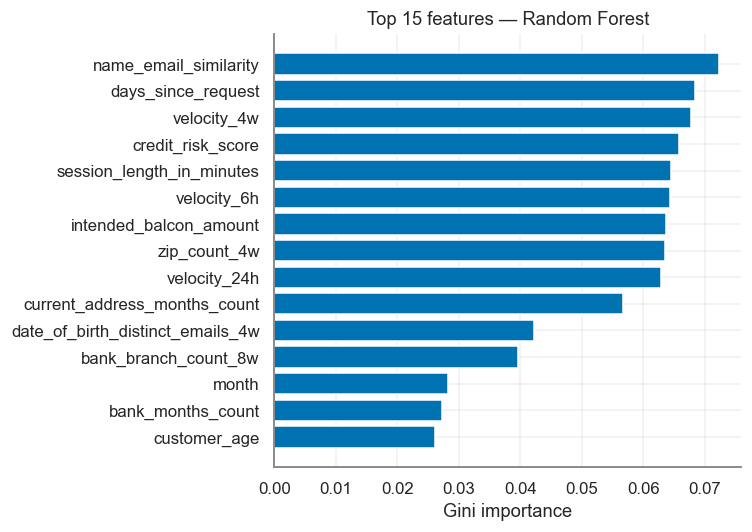

,importance
name_email_similarity,0.0723
days_since_request,0.0685
velocity_4w,0.0677
credit_risk_score,0.0658
session_length_in_minutes,0.0645
velocity_6h,0.0644
intended_balcon_amount,0.0637
zip_count_4w,0.0635
velocity_24h,0.0629
current_address_months_count,0.0567


In [147]:
importances = (pd.Series(rf.feature_importances_, index=X_train_prep.columns)
               .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color=BLUE)
ax.set_xlabel("Gini importance")
ax.set_title("Top 15 features — Random Forest")
plt.tight_layout()
plt.show()
importances.round(4).to_frame("importance")

## 10. SMOTE (naive baseline)

Plain SMOTE applied to the **one-hot encoded** matrix. Interpolating between one-hot columns yields fractional values like `payment_type_AA = 0.37`, which correspond to no real category. This is the known weakness on mixed-type data — included precisely so we can measure it against SMOTE-NC.

In [148]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=SAMPLING_STRATEGY, random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_prep, y_train)

print("After SMOTE:", X_train_sm.shape, "->", dict(y_train_sm.value_counts().sort_index()))

# How many one-hot cells became fractional (i.e. not a valid category)?
onehot_cols = [c for c in feature_names if any(c.startswith(f"{k}_") for k in categorical_features)]
vals = X_train_sm[onehot_cols].to_numpy()
frac = ((vals > 1e-6) & (vals < 1 - 1e-6)).sum()
print(f"Fractional one-hot cells created by SMOTE: {frac:,} "
      f"({frac / vals.size:.2%} of one-hot cells)")

After SMOTE: (870294, 51) -> {0: np.int64(791177), 1: np.int64(79117)}
Fractional one-hot cells created by SMOTE: 132,158 (0.58% of one-hot cells)


In [149]:
rf_smote = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_sm, y_proba_sm, metrics_smote = evaluate(rf_smote, X_test_prep, y_test)
pd.Series(metrics_smote).round(4).to_frame("score")

,score
Accuracy,0.9890
Precision,0.4750
Recall,0.0172
F1-score,0.0332
ROC-AUC,0.8499
PR-AUC,0.1293


## 11. SMOTE-NC (fair baseline)

`SMOTENC` handles mixed types correctly: it interpolates the continuous features but assigns each categorical feature by **majority vote among the neighbours**, so every synthetic row carries a *valid* category. Binary flags are declared categorical too.

This is the honest opponent for CTGAN.

In [150]:
from imblearn.over_sampling import SMOTENC

# Column indices of everything that must be treated as categorical
cat_feature_idx = [X_train_filled.columns.get_loc(c)
                   for c in categorical_features + binary_features]
print(f"Categorical column indices for SMOTE-NC: {cat_feature_idx}")

smnc = SMOTENC(categorical_features=cat_feature_idx,
               sampling_strategy=SAMPLING_STRATEGY, random_state=42)
X_snc, y_snc = smnc.fit_resample(X_train_filled, y_train)

print("After SMOTE-NC:", X_snc.shape, "->", dict(y_snc.value_counts().sort_index()))

# Encode with the preprocessor already fitted on the real training set
X_snc_prep = pd.DataFrame(preprocessor.transform(X_snc), columns=feature_names)
print("Encoded:", X_snc_prep.shape)

Categorical column indices for SMOTE-NC: [6, 13, 16, 23, 25, 15, 17, 18, 20, 22, 26, 28]
After SMOTE-NC: (870294, 30) -> {0: np.int64(791177), 1: np.int64(79117)}
Encoded: (870294, 51)


In [151]:
rf_smotenc = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_smotenc.fit(X_snc_prep, y_snc)

y_pred_snc, y_proba_snc, metrics_smotenc = evaluate(rf_smotenc, X_test_prep, y_test)
pd.Series(metrics_smotenc).round(4).to_frame("score")

,score
Accuracy,0.9873
Precision,0.2515
Recall,0.0752
F1-score,0.1158
ROC-AUC,0.8585
PR-AUC,0.1112


## 12. CTGAN

Now CTGAN is being used for the job it was designed for: a **mixed numerical + categorical** table with enough minority data (~8,800 fraud rows) to estimate a distribution.

`discrete_columns` covers the 5 text categoricals **and** the 7 binary flags, so the generator emits valid categories rather than interpolated nonsense.

### 12.1 Train CTGAN on the fraud minority

In [152]:
from ctgan import CTGAN

CTGAN_EPOCHS = 300   # ~8 s/epoch on CPU (~40 min). Loss was still falling at 100.

# Fraud rows of the TRAINING split only -> no test leakage. Raw mixed-type space.
minority_train = X_train_filled[y_train == 1].copy()

# Several BAF columns are numeric in dtype but genuinely DISCRETE:
#   customer_age          -> 9 levels  (decades only: 10, 20, ... 90)
#   income                -> 9 levels  (0.1 steps)
#   proposed_credit_limit -> 12 tiers  (190, 200, 210, 490, ...)
# Modelled as continuous, CTGAN emits impossible values (customer_age = 35).
# Declaring them discrete routes them through the categorical machinery, so the
# generator can only emit values that actually occur.
DISCRETE_MAX_LEVELS = 25
discrete_numeric = sorted(c for c in numeric_features
                          if X_train_filled[c].nunique() <= DISCRETE_MAX_LEVELS)

discrete_columns = categorical_features + binary_features + discrete_numeric

print(f"CTGAN training on {len(minority_train):,} fraud rows x {minority_train.shape[1]} features")
print(f"Discrete numeric detected ({len(discrete_numeric)}): {discrete_numeric}")
print(f"Total discrete columns: {len(discrete_columns)} / {minority_train.shape[1]}")

CTGAN training on 8,823 fraud rows x 30 features
Discrete numeric detected (5): ['customer_age', 'device_distinct_emails_8w', 'income', 'month', 'proposed_credit_limit']
Total discrete columns: 17 / 30


In [153]:
ctgan = CTGAN(epochs=CTGAN_EPOCHS, verbose=True, cuda=False)
ctgan.fit(minority_train, discrete_columns=discrete_columns)
print("\nCTGAN training complete.")

c:\Users\Upeksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-04.13) | Discrim. (-00.24): 100%|██████████| 300/300 [13:20<00:00,  2.67s/it]


CTGAN training complete.


#### Convergence check

CTGAN's discriminator loss is `-(E[D(real)] - E[D(fake)])`, i.e. the **negative Wasserstein estimate**. Oscillating around 0 means the critic cannot separate real from generated fraud — the signal we want.

Caveat learned the hard way: a converged loss curve does **not** guarantee usable samples. The fidelity checks below are the real gate.

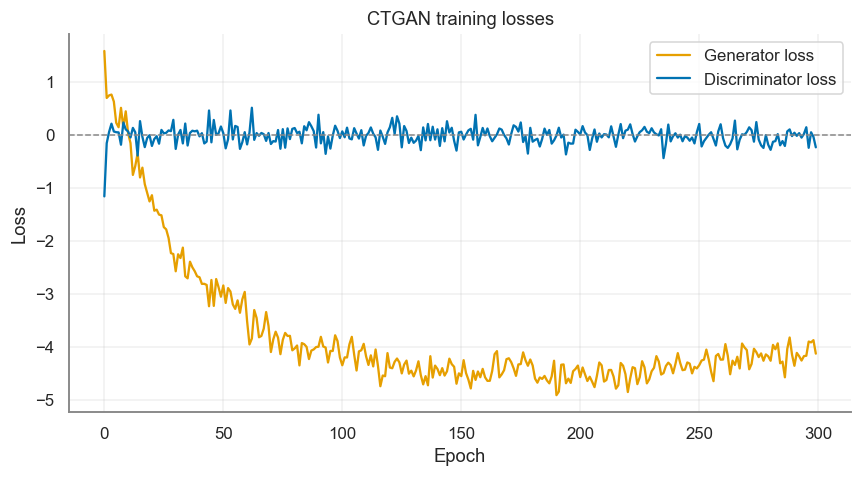

,Epoch,Generator Loss,Discriminator Loss
295,295,-4.166880,0.143162
296,296,-3.898796,-0.244998
297,297,-3.914360,0.048258
298,298,-3.872353,-0.037323
299,299,-4.126845,-0.235747


In [154]:
losses = ctgan.loss_values.copy()

# NB: the ctgan package spells this column "Distriminator Loss" (sic) -> match defensively.
gen_col = next(c for c in losses.columns if "gener" in c.lower())
dis_col = next(c for c in losses.columns if c.lower().startswith(("distr", "discr")))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses["Epoch"], losses[gen_col].astype(float), color=ORANGE, lw=1.5, label="Generator loss")
ax.plot(losses["Epoch"], losses[dis_col].astype(float), color=BLUE, lw=1.5, label="Discriminator loss")
ax.axhline(0, color="#888888", ls="--", lw=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CTGAN training losses")
ax.legend()
plt.tight_layout()
plt.show()

losses.tail()

### 12.2 Generate synthetic fraud

In [155]:
synthetic_fraud = ctgan.sample(n_needed)

print(f"Generated {len(synthetic_fraud):,} synthetic fraud samples")
print(f"Target ratio {SAMPLING_STRATEGY:.0%}: "
      f"{n_minor + n_needed:,} fraud vs {n_major:,} legit")
synthetic_fraud.head()

Generated 70,294 synthetic fraud samples
Target ratio 10%: 79,117 fraud vs 791,177 legit


,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0.9,0.060931,149.894264,30,-0.016874,-1.145217,AC,1269,5397.522787,4691.854131,3165.566127,1751,7,CA,275,1,BA,0,1,25.317997,0,1500.0,0,TELEAPP,13.248358,macintosh,1,1.0,0,4
1,0.8,0.623695,141.055760,40,-0.084809,-1.227160,AB,2300,7360.534871,4101.822456,4400.006549,16,5,CC,319,1,BA,0,1,1.793064,0,1000.0,0,INTERNET,12.443692,windows,0,1.0,0,1
2,0.9,0.203808,126.249209,30,2.550059,-0.715252,AB,846,2761.803798,5875.085097,6121.274903,12,7,CC,103,1,BA,1,0,14.705402,0,1500.0,0,INTERNET,2.500898,windows,0,1.0,0,5
3,0.9,0.177530,70.011025,50,0.110095,-0.524723,AC,969,4126.931190,3046.038589,3154.909541,237,7,CA,203,1,BA,0,1,25.046479,1,200.0,0,INTERNET,18.183741,linux,0,1.0,0,5
4,0.1,0.018067,91.952308,70,8.783254,-1.006133,AA,1983,10119.564200,5548.115936,4035.324269,137,13,CA,54,1,BB,0,1,1.155642,0,2000.0,0,INTERNET,7.819210,other,1,1.0,0,6


#### Fidelity check — numeric features

Marginal distributions of the most target-correlated numeric features, real fraud vs synthetic.

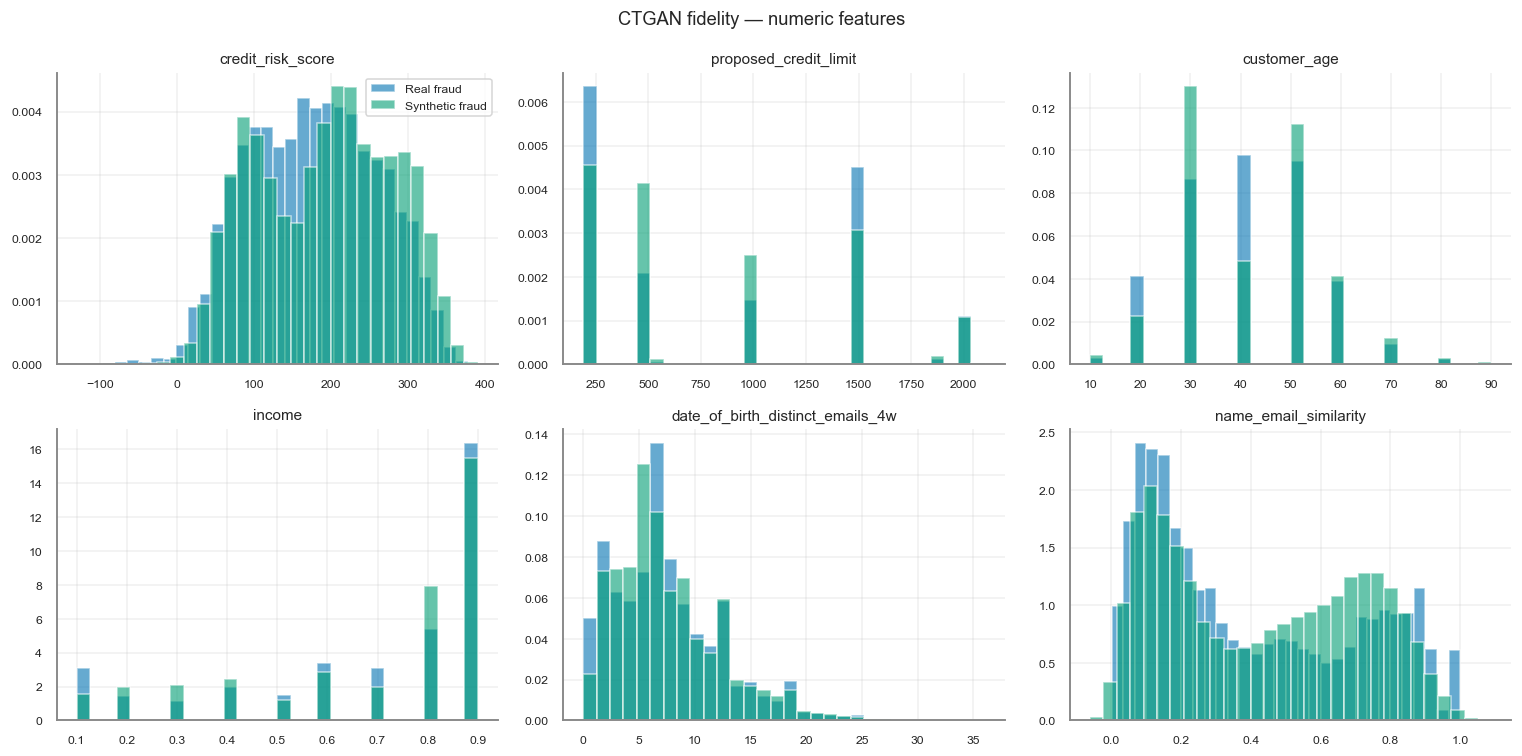

In [156]:
num_check = [c for c in target_corr.index if c in numeric_features][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, num_check):
    ax.hist(minority_train[feat], bins=30, density=True, alpha=0.6,
            color=BLUE, label="Real fraud")
    ax.hist(synthetic_fraud[feat], bins=30, density=True, alpha=0.6,
            color=GREEN, label="Synthetic fraud")
    ax.set_title(feat, fontsize=10)
    ax.tick_params(labelsize=8)
axes.flat[0].legend(fontsize=8)

fig.suptitle("CTGAN fidelity — numeric features", fontsize=12)
plt.tight_layout()
plt.show()

#### Fidelity check — categorical features

**This is the check that matters most on this dataset.** It is the one thing SMOTE structurally cannot do well, so if CTGAN is going to earn its complexity, the category proportions should match closely here.

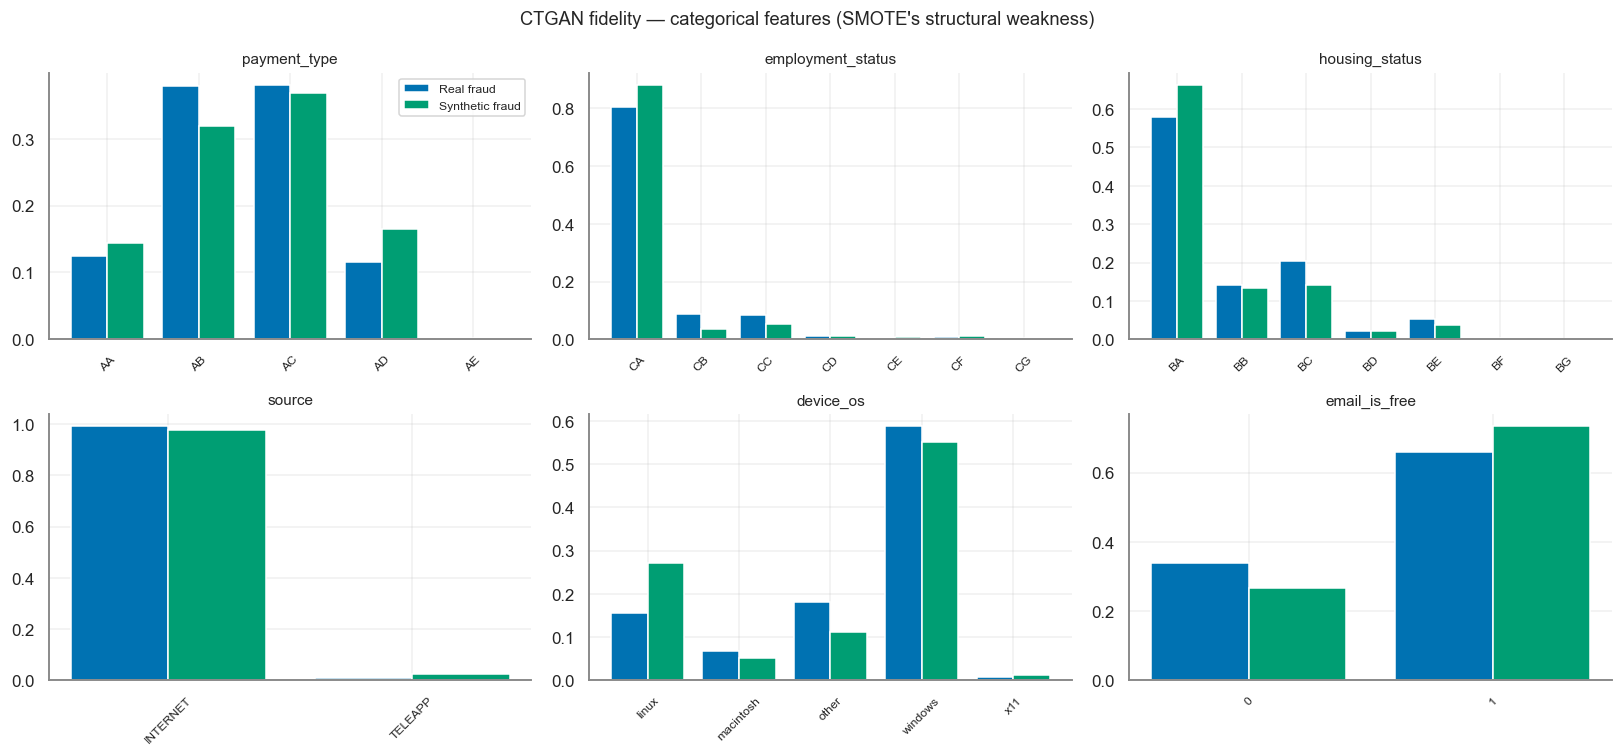

Total variation distance, real vs synthetic (lower is better):
  payment_type         0.0712
  employment_status    0.0840
  housing_status       0.0871
  source               0.0156
  device_os            0.1211


In [157]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, categorical_features + binary_features[:1]):
    real_p = minority_train[feat].value_counts(normalize=True).sort_index()
    syn_p = (synthetic_fraud[feat].value_counts(normalize=True)
             .reindex(real_p.index).fillna(0))
    x = np.arange(len(real_p)); w = 0.4
    ax.bar(x - w / 2, real_p.values, w, color=BLUE, label="Real fraud")
    ax.bar(x + w / 2, syn_p.values, w, color=GREEN, label="Synthetic fraud")
    ax.set_xticks(x)
    ax.set_xticklabels(real_p.index.astype(str), rotation=45, fontsize=8)
    ax.set_title(feat, fontsize=10)
axes.flat[0].legend(fontsize=8)

fig.suptitle("CTGAN fidelity — categorical features (SMOTE's structural weakness)", fontsize=12)
plt.tight_layout()
plt.show()

# Total variation distance per categorical feature (0 = identical, 1 = disjoint)
print("Total variation distance, real vs synthetic (lower is better):")
for feat in categorical_features:
    real_p = minority_train[feat].value_counts(normalize=True)
    syn_p = synthetic_fraud[feat].value_counts(normalize=True).reindex(real_p.index).fillna(0)
    print(f"  {feat:20s} {0.5 * np.abs(real_p - syn_p).sum():.4f}")

In [158]:
# Numeric fidelity summary
fidelity = pd.DataFrame({
    "real_mean": minority_train[numeric_features].mean(),
    "syn_mean":  synthetic_fraud[numeric_features].mean(),
    "real_std":  minority_train[numeric_features].std(),
    "syn_std":   synthetic_fraud[numeric_features].std(),
})
fidelity["mean_diff"] = (fidelity["syn_mean"] - fidelity["real_mean"]).abs()
fidelity["shift_in_sigma"] = (fidelity["mean_diff"] / fidelity["real_std"]).round(3)
fidelity["std_ratio"] = (fidelity["syn_std"] / fidelity["real_std"]).round(3)
print("shift_in_sigma > 0.5 indicates a materially displaced distribution;")
print("std_ratio << 1 indicates mode collapse.\n")
fidelity.sort_values("shift_in_sigma", ascending=False).round(3).head(10)

shift_in_sigma > 0.5 indicates a materially displaced distribution;
std_ratio << 1 indicates mode collapse.



,real_mean,syn_mean,real_std,syn_std,mean_diff,shift_in_sigma,std_ratio
bank_branch_count_8w,132.883,397.489,414.028,669.196,264.606,0.639,1.616
zip_count_4w,1628.531,2041.226,1015.060,1344.630,412.695,0.407,1.325
bank_months_count,16.551,14.724,9.379,9.755,1.827,0.195,1.040
month,3.567,3.990,2.320,2.116,0.422,0.182,0.912
credit_risk_score,177.553,192.312,81.888,87.227,14.760,0.180,1.065
session_length_in_minutes,8.142,9.429,9.552,9.310,1.287,0.135,0.975
velocity_6h,5175.271,5550.297,2916.481,2769.376,375.026,0.129,0.950
intended_balcon_amount,3.917,1.828,16.429,11.493,2.090,0.127,0.700
name_email_similarity,0.394,0.431,0.296,0.282,0.037,0.126,0.954
velocity_24h,4615.241,4772.017,1442.573,1618.978,156.776,0.109,1.122


### 12.3 Train Random Forest on the CTGAN-augmented set

In [159]:
X_train_ctgan = pd.concat([X_train_filled, synthetic_fraud[X_train_filled.columns]],
                          ignore_index=True)
y_train_ctgan = pd.concat([y_train.reset_index(drop=True),
                           pd.Series([1] * len(synthetic_fraud))], ignore_index=True)

X_train_ctgan_prep = pd.DataFrame(
    preprocessor.transform(X_train_ctgan), columns=feature_names)

print("Augmented training set:", X_train_ctgan_prep.shape,
      "->", dict(y_train_ctgan.value_counts().sort_index()))

rf_ctgan = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_ctgan.fit(X_train_ctgan_prep, y_train_ctgan)

y_pred_ct, y_proba_ct, metrics_ctgan = evaluate(rf_ctgan, X_test_prep, y_test)
pd.Series(metrics_ctgan).round(4).to_frame("score")

Augmented training set: (870294, 51) -> {0: np.int64(791177), 1: np.int64(79117)}


,score
Accuracy,0.9882
Precision,0.2369
Recall,0.0308
F1-score,0.0546
ROC-AUC,0.8348
PR-AUC,0.0868


In [160]:
print(classification_report(y_test, y_pred_ct, target_names=["Legit (0)", "Fraud (1)"], digits=4))

              precision    recall  f1-score   support

   Legit (0)     0.9893    0.9989    0.9941    197794
   Fraud (1)     0.2369    0.0308    0.0546      2206

    accuracy                         0.9882    200000
   macro avg     0.6131    0.5149    0.5243    200000
weighted avg     0.9810    0.9882    0.9837    200000



## 13. Final comparison

Four models, identical resampling target, identical test set.

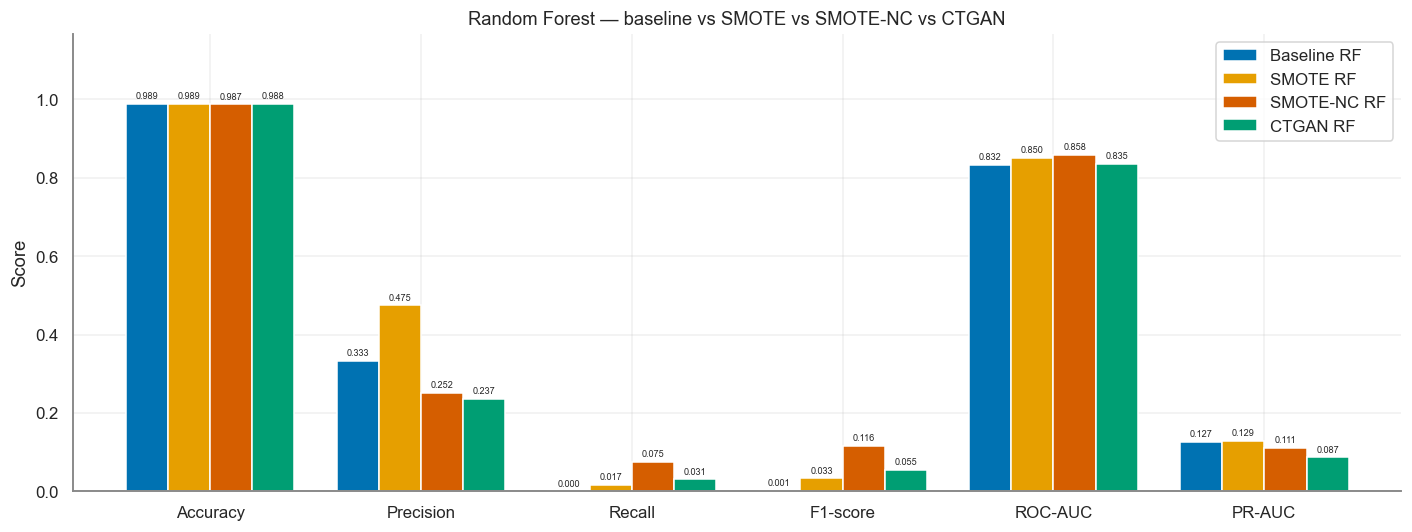

,Baseline RF,SMOTE RF,SMOTE-NC RF,CTGAN RF
Accuracy,0.9890,0.9890,0.9873,0.9882
Precision,0.3333,0.4750,0.2515,0.2369
Recall,0.0005,0.0172,0.0752,0.0308
F1-score,0.0009,0.0332,0.1158,0.0546
ROC-AUC,0.8321,0.8499,0.8585,0.8348
PR-AUC,0.1273,0.1293,0.1112,0.0868


In [161]:
comparison = pd.DataFrame({
    "Baseline RF": metrics,
    "SMOTE RF": metrics_smote,
    "SMOTE-NC RF": metrics_smotenc,
    "CTGAN RF": metrics_ctgan,
})

ax = comparison.plot(kind="bar", figsize=(13, 5),
                     color=[BLUE, ORANGE, VERMILLION, GREEN], width=0.8, rot=0)
ax.set_ylabel("Score")
ax.set_title("Random Forest — baseline vs SMOTE vs SMOTE-NC vs CTGAN")
ax.legend(title=None)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=6, padding=2)
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

comparison.round(4)

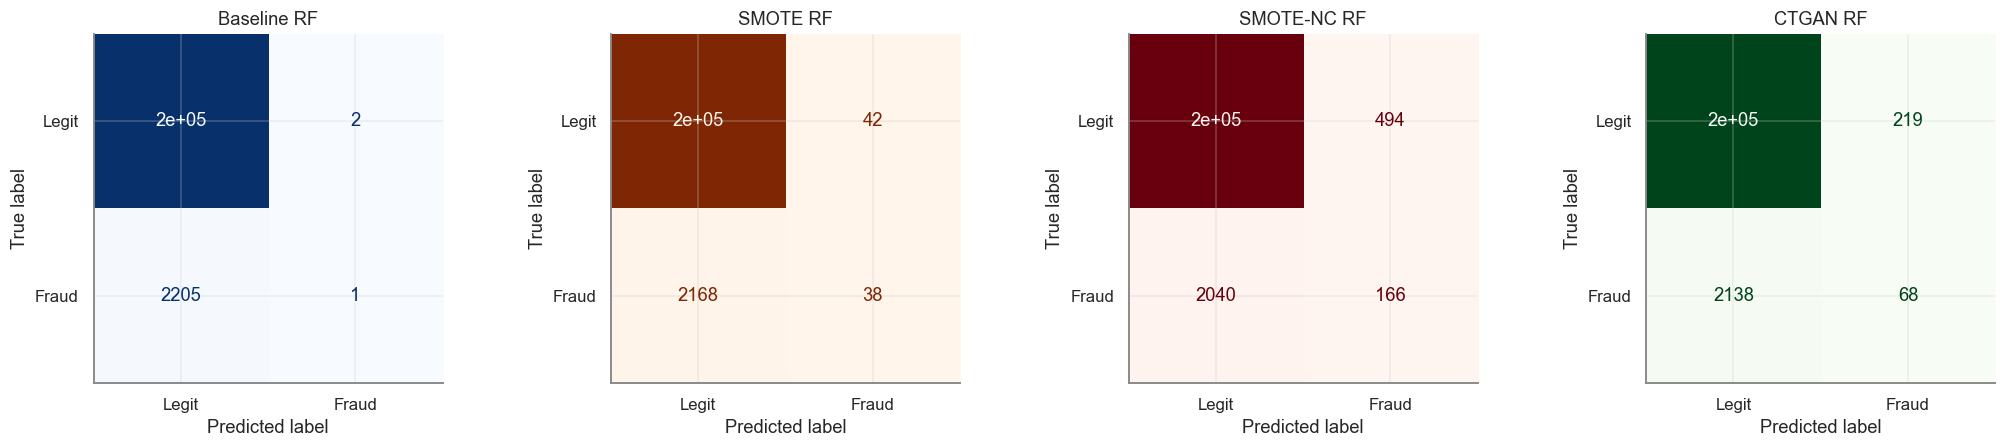

In [162]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, (name, yp, cmap) in zip(axes, [
    ("Baseline RF", y_pred, "Blues"),
    ("SMOTE RF", y_pred_sm, "Oranges"),
    ("SMOTE-NC RF", y_pred_snc, "Reds"),
    ("CTGAN RF", y_pred_ct, "Greens"),
]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
                           display_labels=["Legit", "Fraud"]).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

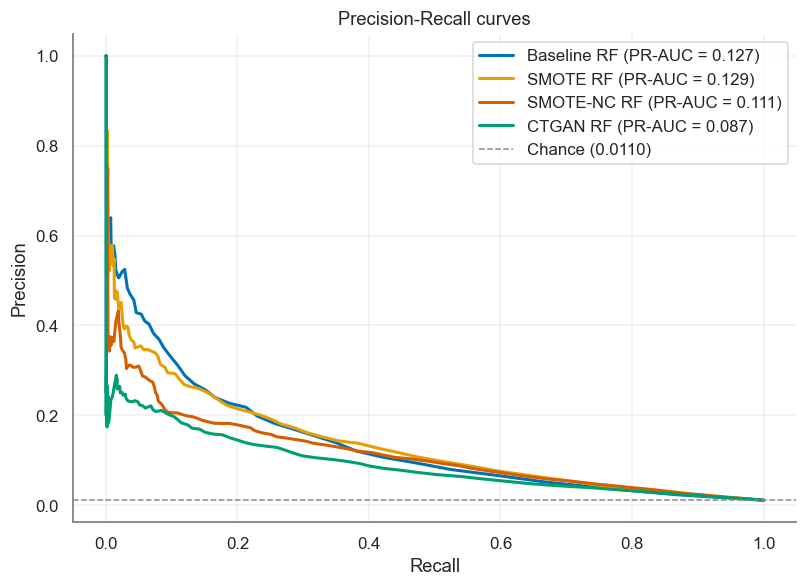

In [163]:
# Precision-Recall curves -- the decisive view at 1:90 imbalance
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, proba, colour in [("Baseline RF", y_proba, BLUE),
                            ("SMOTE RF", y_proba_sm, ORANGE),
                            ("SMOTE-NC RF", y_proba_snc, VERMILLION),
                            ("CTGAN RF", y_proba_ct, GREEN)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=colour, lw=2, label=f"{name} (PR-AUC = {ap:.3f})")

ax.axhline(y_test.mean(), color="#888888", ls="--", lw=1,
           label=f"Chance ({y_test.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 14. The practical alternative — class weights and threshold tuning

Section 13 showed that **no resampler meaningfully beat the baseline on PR-AUC**, yet every model had near-zero recall at the default 0.5 cutoff. That combination is diagnostic: the models *rank* fraud reasonably well (baseline PR-AUC is ~11x the 0.011 chance level) but simply never assign a probability above 0.5.

The bottleneck is the **decision threshold**, not a shortage of synthetic fraud. This section tests the two cheap alternatives:

1. **`class_weight="balanced"`** — reweight the loss instead of fabricating rows.
2. **Threshold tuning** — choose the operating point from the precision-recall curve.

**The threshold is tuned on a validation split carved out of the training data, never on the test set.** Tuning a threshold on test would leak and inflate every number that follows.

### 14.1 `class_weight="balanced"` control

In [164]:
rf_balanced = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=42, class_weight="balanced")
rf_balanced.fit(X_train_prep, y_train)

y_pred_bal, y_proba_bal, metrics_balanced = evaluate(rf_balanced, X_test_prep, y_test)
pd.Series(metrics_balanced).round(4).to_frame("score")

,score
Accuracy,0.9890
Precision,0.8000
Recall,0.0018
F1-score,0.0036
ROC-AUC,0.8236
PR-AUC,0.1117


### 14.2 Threshold tuning

Carve a validation set from the training data, fit there, and pick the threshold on validation. Two operating points:

- **Best-F1** — the balanced compromise.
- **Target recall** — the realistic fraud-operations framing: *"catch 50% of fraud; what precision does that cost?"*

In [165]:
# Validation split carved from TRAIN (test set stays untouched)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.25, stratify=y_train, random_state=42)

rf_fit = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_fit.fit(X_fit, y_fit)

rf_fit_bal = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=42, class_weight="balanced")
rf_fit_bal.fit(X_fit, y_fit)

print(f"Fit: {X_fit.shape[0]:,} rows ({int(y_fit.sum()):,} fraud)")
print(f"Val: {X_val.shape[0]:,} rows ({int(y_val.sum()):,} fraud)")

Fit: 600,000 rows (6,617 fraud)
Val: 200,000 rows (2,206 fraud)


In [166]:
TARGET_RECALL = 0.50


def tune_threshold(model, X_v, y_v, target_recall=TARGET_RECALL):
    """Pick thresholds on VALIDATION data only."""
    proba = model.predict_proba(X_v)[:, 1]
    prec, rec, thr = precision_recall_curve(y_v, proba)
    # prec/rec have one more element than thr; drop the last to align
    p, r = prec[:-1], rec[:-1]
    f1 = 2 * p * r / (p + r + 1e-12)

    i_f1 = int(np.nanargmax(f1))
    ok = np.where(r >= target_recall)[0]
    i_rec = int(ok[-1]) if len(ok) else 0   # highest threshold still meeting the target

    return {
        "thr_best_f1": float(thr[i_f1]),
        "val_f1": float(f1[i_f1]), "val_prec": float(p[i_f1]), "val_rec": float(r[i_f1]),
        "thr_target_recall": float(thr[i_rec]),
        "val_prec_at_target": float(p[i_rec]), "val_rec_at_target": float(r[i_rec]),
    }


tuned_plain = tune_threshold(rf_fit, X_val, y_val)
tuned_bal = tune_threshold(rf_fit_bal, X_val, y_val)

print("Default RF   :", {k: round(v, 4) for k, v in tuned_plain.items()})
print("Balanced RF  :", {k: round(v, 4) for k, v in tuned_bal.items()})

Default RF   : {'thr_best_f1': 0.13, 'val_f1': 0.2036, 'val_prec': 0.1869, 'val_rec': 0.2235, 'thr_target_recall': 0.05, 'val_prec_at_target': 0.0795, 'val_rec_at_target': 0.5317}
Balanced RF  : {'thr_best_f1': 0.09, 'val_f1': 0.1905, 'val_prec': 0.1522, 'val_rec': 0.2543, 'thr_target_recall': 0.03, 'val_prec_at_target': 0.0606, 'val_rec_at_target': 0.5934}


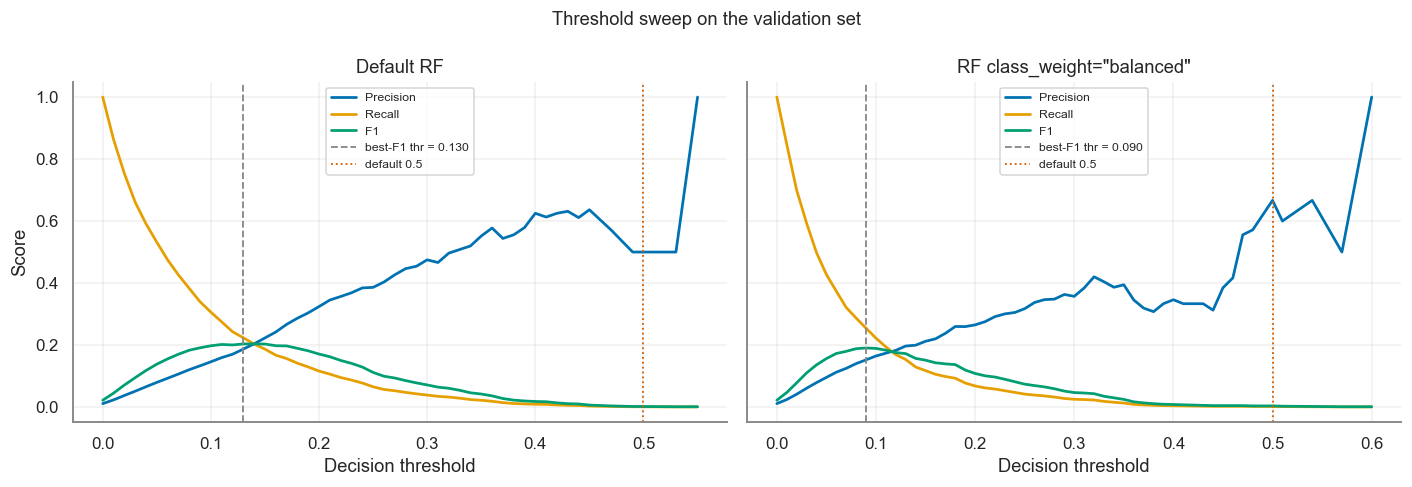

In [167]:
# Precision / recall / F1 across thresholds, measured on VALIDATION
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, (model, name, tuned) in zip(axes, [
    (rf_fit, "Default RF", tuned_plain),
    (rf_fit_bal, 'RF class_weight="balanced"', tuned_bal),
]):
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, proba)
    p, r = prec[:-1], rec[:-1]
    f1 = 2 * p * r / (p + r + 1e-12)

    ax.plot(thr, p, color=BLUE, lw=1.8, label="Precision")
    ax.plot(thr, r, color=ORANGE, lw=1.8, label="Recall")
    ax.plot(thr, f1, color=GREEN, lw=1.8, label="F1")
    ax.axvline(tuned["thr_best_f1"], color="#888888", ls="--", lw=1.2,
               label=f"best-F1 thr = {tuned['thr_best_f1']:.3f}")
    ax.axvline(0.5, color=VERMILLION, ls=":", lw=1.2, label="default 0.5")
    ax.set_xlabel("Decision threshold")
    ax.set_title(name)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Score")
fig.suptitle("Threshold sweep on the validation set", fontsize=12)
plt.tight_layout()
plt.show()

In [168]:
def evaluate_at(model, X_te, y_te, thr):
    """Metrics at an arbitrary threshold. ROC-AUC / PR-AUC are threshold-independent."""
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= thr).astype(int)
    return {
        "Accuracy":  accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall":    recall_score(y_te, pred),
        "F1-score":  f1_score(y_te, pred),
        "ROC-AUC":   roc_auc_score(y_te, proba),
        "PR-AUC":    average_precision_score(y_te, proba),
    }


metrics_thr_f1 = evaluate_at(rf_fit, X_test_prep, y_test, tuned_plain["thr_best_f1"])
metrics_thr_rec = evaluate_at(rf_fit, X_test_prep, y_test, tuned_plain["thr_target_recall"])
metrics_bal_f1 = evaluate_at(rf_fit_bal, X_test_prep, y_test, tuned_bal["thr_best_f1"])

tuned_table = pd.DataFrame({
    "RF @ 0.5 (default)": evaluate_at(rf_fit, X_test_prep, y_test, 0.5),
    "RF @ best-F1 thr": metrics_thr_f1,
    f"RF @ recall>={TARGET_RECALL:.0%} thr": metrics_thr_rec,
    "RF balanced @ best-F1 thr": metrics_bal_f1,
})
tuned_table.round(4)

,RF @ 0.5 (default),RF @ best-F1 thr,RF @ recall>=50% thr,RF balanced @ best-F1 thr
Accuracy,0.9890,0.9812,0.9273,0.9764
Precision,1.0000,0.1967,0.0799,0.1561
Recall,0.0018,0.2294,0.5317,0.2588
F1-score,0.0036,0.2118,0.1390,0.1947
ROC-AUC,0.8300,0.8300,0.8300,0.8275
PR-AUC,0.1268,0.1268,0.1268,0.1070


### 14.3 Everything together

All eight configurations on the same untouched test set. **PR-AUC and ROC-AUC are identical for every threshold variant of the same model** — moving the cutoff trades precision against recall but cannot improve the ranking. That is precisely the point: threshold tuning converts an already-good ranking into usable predictions, whereas resampling was trying (and failing) to improve the ranking itself.

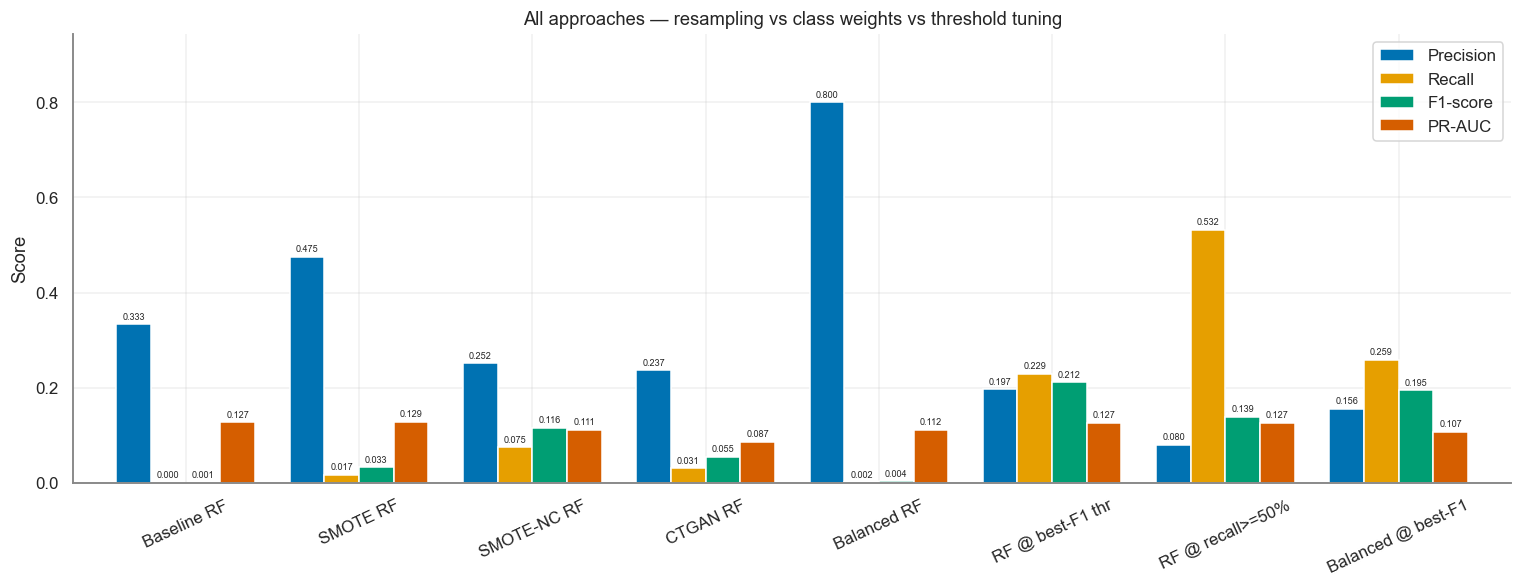

,Baseline RF,SMOTE RF,SMOTE-NC RF,CTGAN RF,Balanced RF,RF @ best-F1 thr,RF @ recall>=50%,Balanced @ best-F1
Accuracy,0.9890,0.9890,0.9873,0.9882,0.9890,0.9812,0.9273,0.9764
Precision,0.3333,0.4750,0.2515,0.2369,0.8000,0.1967,0.0799,0.1561
Recall,0.0005,0.0172,0.0752,0.0308,0.0018,0.2294,0.5317,0.2588
F1-score,0.0009,0.0332,0.1158,0.0546,0.0036,0.2118,0.1390,0.1947
ROC-AUC,0.8321,0.8499,0.8585,0.8348,0.8236,0.8300,0.8300,0.8275
PR-AUC,0.1273,0.1293,0.1112,0.0868,0.1117,0.1268,0.1268,0.1070


In [169]:
final = pd.DataFrame({
    "Baseline RF": metrics,
    "SMOTE RF": metrics_smote,
    "SMOTE-NC RF": metrics_smotenc,
    "CTGAN RF": metrics_ctgan,
    "Balanced RF": metrics_balanced,
    "RF @ best-F1 thr": metrics_thr_f1,
    f"RF @ recall>={TARGET_RECALL:.0%}": metrics_thr_rec,
    "Balanced @ best-F1": metrics_bal_f1,
})

fig, ax = plt.subplots(figsize=(14, 5.5))
final.T[["Precision", "Recall", "F1-score", "PR-AUC"]].plot(
    kind="bar", ax=ax, color=[BLUE, ORANGE, GREEN, VERMILLION], width=0.8, rot=25)
ax.set_ylabel("Score")
ax.set_title("All approaches — resampling vs class weights vs threshold tuning")
ax.legend(title=None)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=6, padding=2)
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

final.round(4)

In [170]:
# Fraud caught vs false alarms -- the operational view
n_fraud = int(y_test.sum())
rows = []
for name, m in final.items():
    tp = m["Recall"] * n_fraud
    fp = tp / m["Precision"] - tp if m["Precision"] > 0 else np.nan
    rows.append({"model": name,
                 "frauds_caught": int(round(tp)),
                 "frauds_missed": int(round(n_fraud - tp)),
                 "false_alarms": int(round(fp)) if np.isfinite(fp) else None})

print(f"Test set: {len(y_test):,} applications, {n_fraud:,} fraudulent\n")
pd.DataFrame(rows).set_index("model")

Test set: 200,000 applications, 2,206 fraudulent



,frauds_caught,frauds_missed,false_alarms
model,,,
Baseline RF,1,2205,2
SMOTE RF,38,2168,42
SMOTE-NC RF,166,2040,494
CTGAN RF,68,2138,219
Balanced RF,4,2202,1
RF @ best-F1 thr,506,1700,2066
RF @ recall>=50%,1173,1033,13502
Balanced @ best-F1,571,1635,3088
